<a href="https://colab.research.google.com/github/manasatm24/titanic/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
data = pd.read_csv("/content/Titanic-Dataset.csv")

In [4]:
print(data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
data['Age'].fillna(data['Age'].mean(), inplace=True)

/tmp/ipykernel_10265/1981374165.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)


In [6]:
data.drop(['Name', 'PassengerId'], axis=1, inplace=True)

In [7]:
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

In [8]:
data['FamilySize'] = data['SibSp'] + data['Parch']

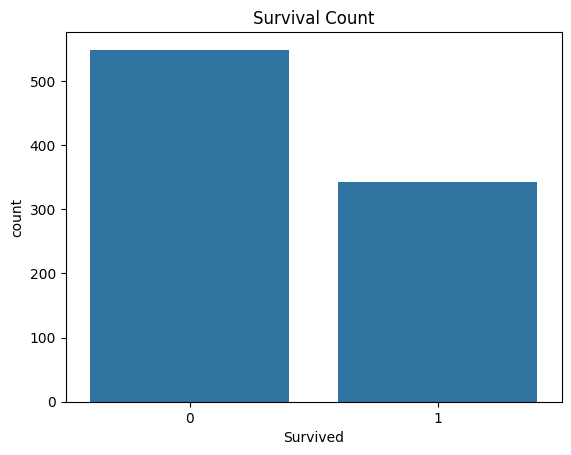

In [9]:
sns.countplot(x='Survived', data=data)
plt.title("Survival Count")
plt.show()

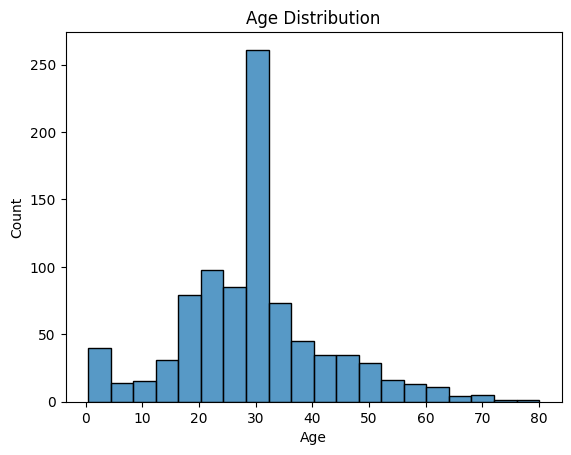

In [10]:
sns.histplot(data['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

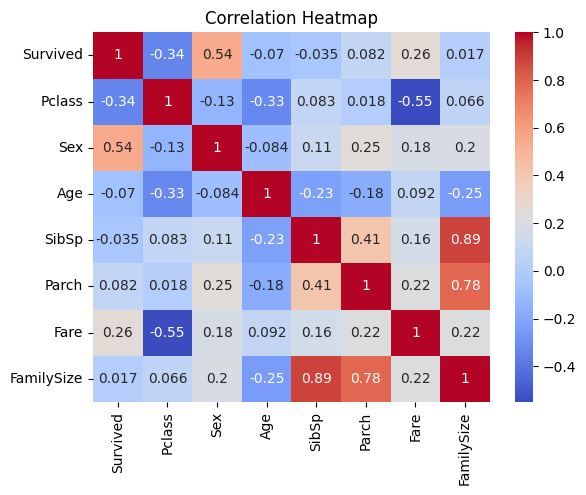

In [12]:
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
X = data[['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize']]
y = data['Survived']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [19]:
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8044692737430168
Confusion Matrix:
 [[92 13]
 [22 52]]


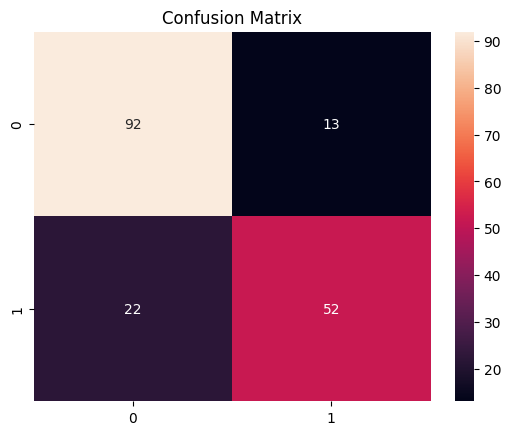

In [23]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()